## Classification of skin tumors from multi-colored images (3 channels)
Tool used: PyTorch

In [1]:
# Core imports
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import medmnist
from medmnist import INFO
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
data_flag = "dermamnist"
info = INFO[data_flag]
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [4]:
n_channels = info["n_channels"]
n_classes = len(info["label"])

print("Number of input channels:", n_channels)
print("Number of original classes:", n_classes)
print("Original label mapping:")
for k, v in info["label"].items():
    print(f"  {k}: {v}")

Number of input channels: 3
Number of original classes: 7
Original label mapping:
  0: actinic keratoses and intraepithelial carcinoma
  1: basal cell carcinoma
  2: benign keratosis-like lesions
  3: dermatofibroma
  4: melanoma
  5: melanocytic nevi
  6: vascular lesions


In [5]:
from torchvision import transforms

# Basic image transform:
# - convert image to tensor
# - normalize roughly to centered values
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*n_channels, std=[0.5]*n_channels)
])

DataClass = getattr(medmnist, info["python_class"])

train_base = DataClass(split="train", transform=basic_transform, download=True)
val_base   = DataClass(split="val",   transform=basic_transform, download=True)
test_base  = DataClass(split="test",  transform=basic_transform, download=True)

print("Train size:", len(train_base))
print("Val size:", len(val_base))
print("Test size:", len(test_base))

Train size: 7007
Val size: 1003
Test size: 2005


In [6]:

HIGHER_RISK_CLASSES = {0, 1, 4}

def make_binary_target(class_idx: int) -> int:
    return 1 if class_idx in HIGHER_RISK_CLASSES else 0

print("Higher-risk class indices:", HIGHER_RISK_CLASSES)
for k, v in info["label"].items():
    print(f"class {k}: {v} -> binary target {make_binary_target(int(k))}")

Higher-risk class indices: {0, 1, 4}
class 0: actinic keratoses and intraepithelial carcinoma -> binary target 1
class 1: basal cell carcinoma -> binary target 1
class 2: benign keratosis-like lesions -> binary target 0
class 3: dermatofibroma -> binary target 0
class 4: melanoma -> binary target 1
class 5: melanocytic nevi -> binary target 0
class 6: vascular lesions -> binary target 0


In [8]:
class MultiHeadDermaMNIST(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, label = self.base[idx]

        class_label = int(label.squeeze())
        binary_label = make_binary_target(class_label)

        return image, {
            "class_label": torch.tensor(class_label, dtype=torch.long),
            "binary_label": torch.tensor(binary_label, dtype=torch.long)
        }

train_dataset = MultiHeadDermaMNIST(train_base)
val_dataset = MultiHeadDermaMNIST(val_base)
test_dataset = MultiHeadDermaMNIST(test_base)

In [9]:
train_dataset.base

Dataset DermaMNIST of size 28 (dermamnist)
    Number of datapoints: 7007
    Root location: /Users/josoga2/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
    Number of samples: {'train': 7007, 'val': 1003, 'test': 2005}
    Description: The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.
    License: CC BY-NC 4.0

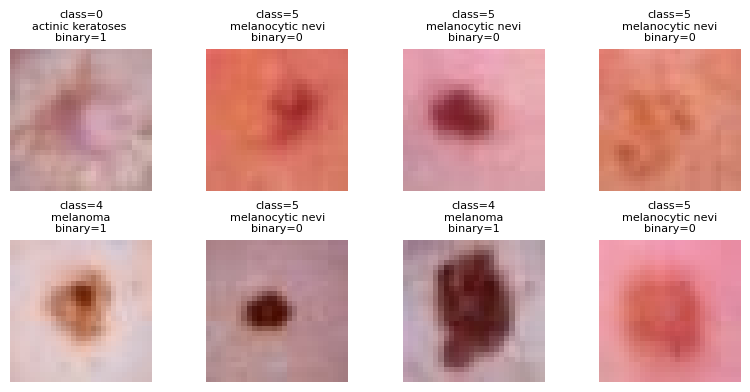

In [10]:
def denormalize(img_tensor):
    return img_tensor * 0.5 + 0.5

def show_samples(dataset, num_samples=8):
    plt.figure(figsize=(8, 4))
    for i in range(num_samples):
        image, targets = dataset[i]
        class_idx = targets["class_label"].item()
        binary_idx = targets["binary_label"].item()

        class_name = info["label"][str(class_idx)]

        plt.subplot(2, num_samples // 2, i + 1)
        img = denormalize(image).permute(1, 2, 0).cpu().numpy()

        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)

        plt.title(f"class={class_idx}\n{class_name[:18]}\nbinary={binary_idx}", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, num_samples=8)

In [11]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

images, targets = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Class labels shape:", targets["class_label"].shape)
print("Binary labels shape:", targets["binary_label"].shape)

Image batch shape: torch.Size([128, 3, 28, 28])
Class labels shape: torch.Size([128])
Binary labels shape: torch.Size([128])


In [12]:
class MultiHeadCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=7, num_binary=2, dropout=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.class_head = nn.Linear(128, num_classes)
        self.binary_head = nn.Linear(128, num_binary)

    def forward(self, x):
        x = self.features(x)
        x = self.shared_fc(x)

        class_logits = self.class_head(x)
        binary_logits = self.binary_head(x)

        return {
            "class_logits": class_logits,
            "binary_logits": binary_logits
        }

model = MultiHeadCNN(
    in_channels=n_channels,
    num_classes=n_classes,
    num_binary=2,
    dropout=0.3
).to(device)

model

MultiHeadCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (shared_fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (class_head): Linear(in_features=128, out_features=7, bias=True)
  (binary_head): Linear(in_features=128, out_features=2, bias=True)
)

In [13]:
sample_batch = images[:4].to(device)

with torch.no_grad():
    x = sample_batch
    print("Input:", x.shape)

    for i, layer in enumerate(model.features):
        x = layer(x)
        print(f"After features layer {i} ({layer.__class__.__name__}): {x.shape}")

    shared = model.shared_fc(x)
    print("After shared_fc:", shared.shape)

    class_logits = model.class_head(shared)
    binary_logits = model.binary_head(shared)

    print("Class head output:", class_logits.shape)
    print("Binary head output:", binary_logits.shape)

Input: torch.Size([4, 3, 28, 28])
After features layer 0 (Conv2d): torch.Size([4, 16, 28, 28])
After features layer 1 (ReLU): torch.Size([4, 16, 28, 28])
After features layer 2 (MaxPool2d): torch.Size([4, 16, 14, 14])
After features layer 3 (Conv2d): torch.Size([4, 32, 14, 14])
After features layer 4 (ReLU): torch.Size([4, 32, 14, 14])
After features layer 5 (MaxPool2d): torch.Size([4, 32, 7, 7])
After features layer 6 (Conv2d): torch.Size([4, 64, 7, 7])
After features layer 7 (ReLU): torch.Size([4, 64, 7, 7])
After features layer 8 (MaxPool2d): torch.Size([4, 64, 3, 3])
After shared_fc: torch.Size([4, 128])
Class head output: torch.Size([4, 7])
Binary head output: torch.Size([4, 2])


In [17]:
class_criterion = nn.CrossEntropyLoss()
binary_criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

alpha = 1.0
beta = 0.5

print("alpha =", alpha)
print("beta =", beta)

alpha = 1.0
beta = 0.5


In [18]:
def train_one_epoch(model, loader, optimizer, class_criterion, binary_criterion, device, alpha=1.0, beta=0.5):
    model.train()

    total_loss_sum = 0.0
    class_loss_sum = 0.0
    binary_loss_sum = 0.0

    class_correct = 0
    binary_correct = 0
    total = 0

    for images, targets in loader:
        images = images.to(device)
        class_labels = targets["class_label"].to(device)
        binary_labels = targets["binary_label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        class_logits = outputs["class_logits"]
        binary_logits = outputs["binary_logits"]

        class_loss = class_criterion(class_logits, class_labels)
        binary_loss = binary_criterion(binary_logits, binary_labels)
        total_loss = alpha * class_loss + beta * binary_loss

        total_loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total += batch_size

        total_loss_sum += total_loss.item() * batch_size
        class_loss_sum += class_loss.item() * batch_size
        binary_loss_sum += binary_loss.item() * batch_size

        class_preds = class_logits.argmax(dim=1)
        binary_preds = binary_logits.argmax(dim=1)

        class_correct += (class_preds == class_labels).sum().item()
        binary_correct += (binary_preds == binary_labels).sum().item()

    return {
        "total_loss": total_loss_sum / total,
        "class_loss": class_loss_sum / total,
        "binary_loss": binary_loss_sum / total,
        "class_acc": class_correct / total,
        "binary_acc": binary_correct / total,
    }


@torch.no_grad()
def evaluate(model, loader, class_criterion, binary_criterion, device, alpha=1.0, beta=0.5):
    model.eval()

    total_loss_sum = 0.0
    class_loss_sum = 0.0
    binary_loss_sum = 0.0

    class_correct = 0
    binary_correct = 0
    total = 0

    all_class_labels = []
    all_class_preds = []
    all_binary_labels = []
    all_binary_preds = []

    for images, targets in loader:
        images = images.to(device)
        class_labels = targets["class_label"].to(device)
        binary_labels = targets["binary_label"].to(device)

        outputs = model(images)
        class_logits = outputs["class_logits"]
        binary_logits = outputs["binary_logits"]

        class_loss = class_criterion(class_logits, class_labels)
        binary_loss = binary_criterion(binary_logits, binary_labels)
        total_loss = alpha * class_loss + beta * binary_loss

        batch_size = images.size(0)
        total += batch_size

        total_loss_sum += total_loss.item() * batch_size
        class_loss_sum += class_loss.item() * batch_size
        binary_loss_sum += binary_loss.item() * batch_size

        class_preds = class_logits.argmax(dim=1)
        binary_preds = binary_logits.argmax(dim=1)

        class_correct += (class_preds == class_labels).sum().item()
        binary_correct += (binary_preds == binary_labels).sum().item()

        all_class_labels.extend(class_labels.cpu().numpy().tolist())
        all_class_preds.extend(class_preds.cpu().numpy().tolist())
        all_binary_labels.extend(binary_labels.cpu().numpy().tolist())
        all_binary_preds.extend(binary_preds.cpu().numpy().tolist())

    return {
        "total_loss": total_loss_sum / total,
        "class_loss": class_loss_sum / total,
        "binary_loss": binary_loss_sum / total,
        "class_acc": class_correct / total,
        "binary_acc": binary_correct / total,
        "all_class_labels": all_class_labels,
        "all_class_preds": all_class_preds,
        "all_binary_labels": all_binary_labels,
        "all_binary_preds": all_binary_preds,
    }

In [19]:
num_epochs = 8

history = {
    "train_total_loss": [],
    "val_total_loss": [],
    "train_class_acc": [],
    "val_class_acc": [],
    "train_binary_acc": [],
    "val_binary_acc": [],
}

best_val_class_acc = 0.0
best_state = None

for epoch in range(1, num_epochs + 1):
    train_metrics = train_one_epoch(
        model, train_loader, optimizer,
        class_criterion, binary_criterion, device,
        alpha=alpha, beta=beta
    )

    val_metrics = evaluate(
        model, val_loader,
        class_criterion, binary_criterion, device,
        alpha=alpha, beta=beta
    )

    history["train_total_loss"].append(train_metrics["total_loss"])
    history["val_total_loss"].append(val_metrics["total_loss"])
    history["train_class_acc"].append(train_metrics["class_acc"])
    history["val_class_acc"].append(val_metrics["class_acc"])
    history["train_binary_acc"].append(train_metrics["binary_acc"])
    history["val_binary_acc"].append(val_metrics["binary_acc"])

    if val_metrics["class_acc"] > best_val_class_acc:
        best_val_class_acc = val_metrics["class_acc"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss: {train_metrics['total_loss']:.4f} | "
        f"Val loss: {val_metrics['total_loss']:.4f} | "
        f"Train class acc: {train_metrics['class_acc']:.4f} | "
        f"Val class acc: {val_metrics['class_acc']:.4f} | "
        f"Train binary acc: {train_metrics['binary_acc']:.4f} | "
        f"Val binary acc: {val_metrics['binary_acc']:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model based on validation class accuracy.")

Epoch 01 | Train loss: 1.4089 | Val loss: 1.2202 | Train class acc: 0.6449 | Val class acc: 0.6690 | Train binary acc: 0.7931 | Val binary acc: 0.8046
Epoch 02 | Train loss: 1.1764 | Val loss: 1.1083 | Train class acc: 0.6698 | Val class acc: 0.6690 | Train binary acc: 0.8053 | Val binary acc: 0.8046
Epoch 03 | Train loss: 1.1102 | Val loss: 1.0611 | Train class acc: 0.6746 | Val class acc: 0.6830 | Train binary acc: 0.8042 | Val binary acc: 0.8046
Epoch 04 | Train loss: 1.0593 | Val loss: 0.9986 | Train class acc: 0.6886 | Val class acc: 0.6929 | Train binary acc: 0.8055 | Val binary acc: 0.8046
Epoch 05 | Train loss: 1.0279 | Val loss: 0.9826 | Train class acc: 0.6969 | Val class acc: 0.6989 | Train binary acc: 0.8106 | Val binary acc: 0.8116
Epoch 06 | Train loss: 1.0026 | Val loss: 0.9687 | Train class acc: 0.6986 | Val class acc: 0.6979 | Train binary acc: 0.8136 | Val binary acc: 0.8185
Epoch 07 | Train loss: 0.9806 | Val loss: 0.9586 | Train class acc: 0.7053 | Val class acc: 0.

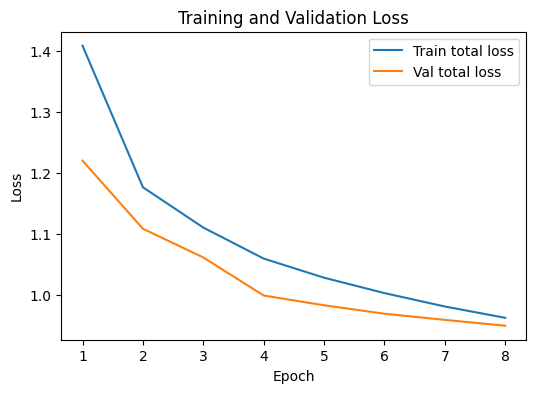

In [20]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_total_loss"], label="Train total loss")
plt.plot(epochs, history["val_total_loss"], label="Val total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

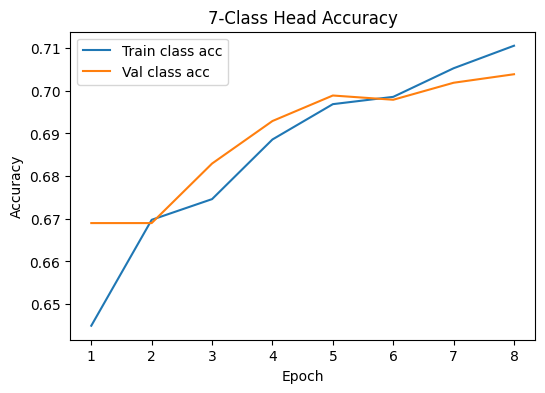

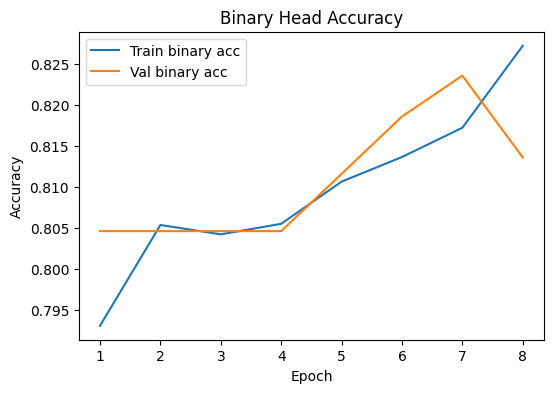

In [21]:

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_class_acc"], label="Train class acc")
plt.plot(epochs, history["val_class_acc"], label="Val class acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("7-Class Head Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_binary_acc"], label="Train binary acc")
plt.plot(epochs, history["val_binary_acc"], label="Val binary acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Binary Head Accuracy")
plt.legend()
plt.show()

In [22]:
test_metrics = evaluate(
    model, test_loader,
    class_criterion, binary_criterion, device,
    alpha=alpha, beta=beta
)

print("Test total loss:", round(test_metrics["total_loss"], 4))
print("Test class-head accuracy:", round(test_metrics["class_acc"], 4))
print("Test binary-head accuracy:", round(test_metrics["binary_acc"], 4))

Test total loss: 0.9764
Test class-head accuracy: 0.7102
Test binary-head accuracy: 0.8095


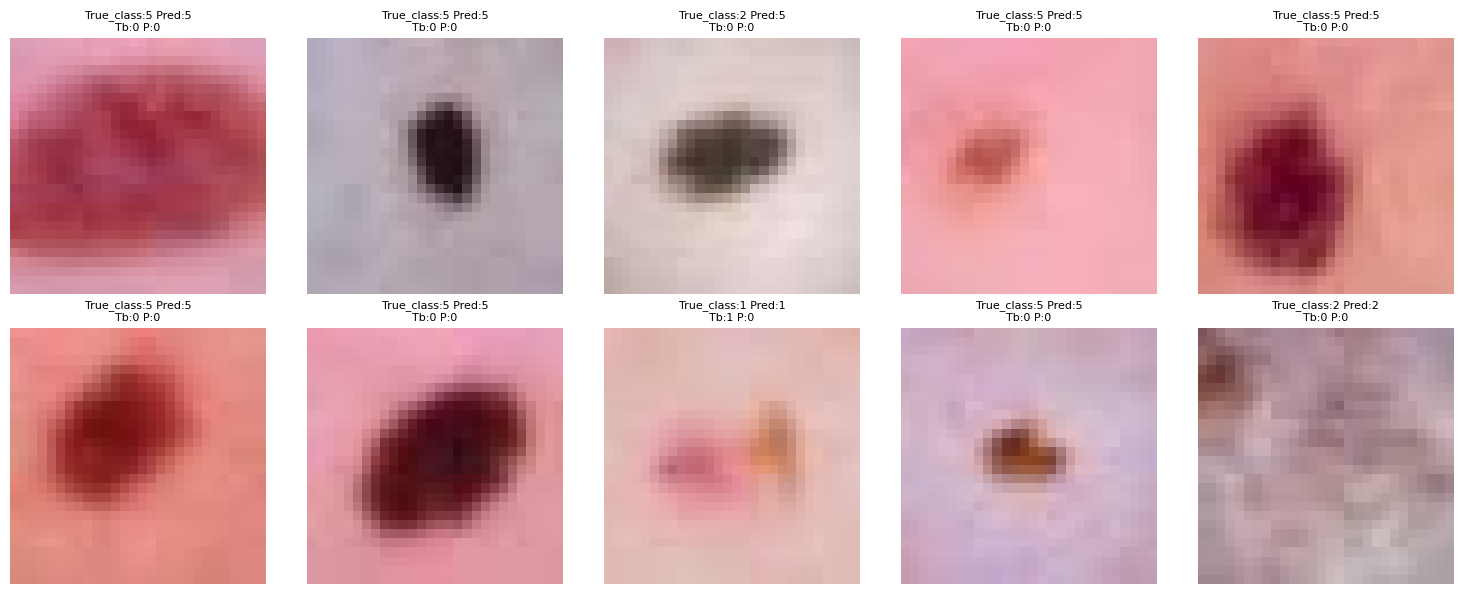

In [27]:
@torch.no_grad()
def show_predictions(model, dataset, num_samples=10):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        image, targets = dataset[idx]
        x = image.unsqueeze(0).to(device)

        outputs = model(x)
        class_pred = outputs["class_logits"].argmax(dim=1).item()
        binary_pred = outputs["binary_logits"].argmax(dim=1).item()

        true_class = targets["class_label"].item()
        true_binary = targets["binary_label"].item()

        img = denormalize(image).permute(1, 2, 0).cpu().numpy()

        plt.subplot(2, 5, i + 1)
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)

        plt.title(
            f"True_class:{true_class} Pred:{class_pred}\nTb:{true_binary} P:{binary_pred}",
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, test_dataset, num_samples=10)